In [1]:
# Plotting regional mortality changes spatially

In [2]:
import xarray as xr
import regionmask
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

In [3]:
# === Figure sizing ===
def autosize_figure(nrows, ncolumns, scale_factor=1, xscale_factor=1, yscale_factor=1):
    xwidth = (ncolumns+0.67) * 5.0 * scale_factor * xscale_factor
    ylength = (nrows+0.67) * 3.6 * scale_factor * yscale_factor
    return (xwidth, ylength)


# === Removing ocean ===
def land_filter(da):
    # Load in land fraction dataset
    land_110 = regionmask.defined_regions.natural_earth_v4_1_0.land_110
    da = da.where(land_110.mask_3D(da).squeeze())
    return da

In [4]:
# === Path config ===
DIR = "/glade/work/awells/air_quality/CESM/mortality/"
BMR_DIR = "/glade/work/awells/air_quality/BMR/"

ssp245 = xr.open_dataarray(f"{DIR}Mortality_Regional_sum_CESM2_SSP245_2020-2069.nc")
arise = xr.open_dataarray(f"{DIR}Mortality_Regional_sum_CESM2_ARISE_2035-2069.nc")
region_mask = xr.open_dataarray(f"{BMR_DIR}GBD_Region_Masks_0.10_popgrid.nc")

In [5]:
# Create DataArray filled with NaNs
regional_mortality_ssp245 = xr.DataArray(
    np.full((len(region_mask.lat), len(region_mask.lon)), np.nan),
    coords={"lat": region_mask.lat.values, "lon": region_mask.lon.values},
    dims=["lat", "lon"]
)

ssp245_mean = ssp245.mean("ensemble")

# Loop over regions, add the mortality for each region and apply using region mask
for i in range(21):
    mask = region_mask.isel(region=i)
    region = mask["region"]
    ssp245_region = ssp245_mean.sel(region=region) # adds all years
    regional_mortality_ssp245 = regional_mortality_ssp245.where(mask == 0, ssp245_region)

In [6]:
# Create DataArray filled with NaNs
regional_mortality_arise = xr.DataArray(
    np.full((len(region_mask.lat), len(region_mask.lon)), np.nan),
    coords={"lat": region_mask.lat.values, "lon": region_mask.lon.values},
    dims=["lat", "lon"]
)

arise_mean = arise.mean("ensemble")

# Loop over regions, add the mortality for each region and apply using region mask
for i in range(21):
    mask = region_mask.isel(region=i)
    region = mask["region"]
    arise_region = arise_mean.sel(region=region) # adds all years
    regional_mortality_arise = regional_mortality_arise.where(mask == 0, arise_region)

In [7]:
diff_30s = (regional_mortality_arise - regional_mortality_ssp245).sel(year=slice(2035, 2039)).mean("year")
diff_40s = (regional_mortality_arise - regional_mortality_ssp245).sel(year=slice(2040, 2049)).mean("year")
diff_50s = (regional_mortality_arise - regional_mortality_ssp245).sel(year=slice(2050, 2059)).mean("year")
diff_60s = (regional_mortality_arise - regional_mortality_ssp245).sel(year=slice(2060, 2069)).mean("year")

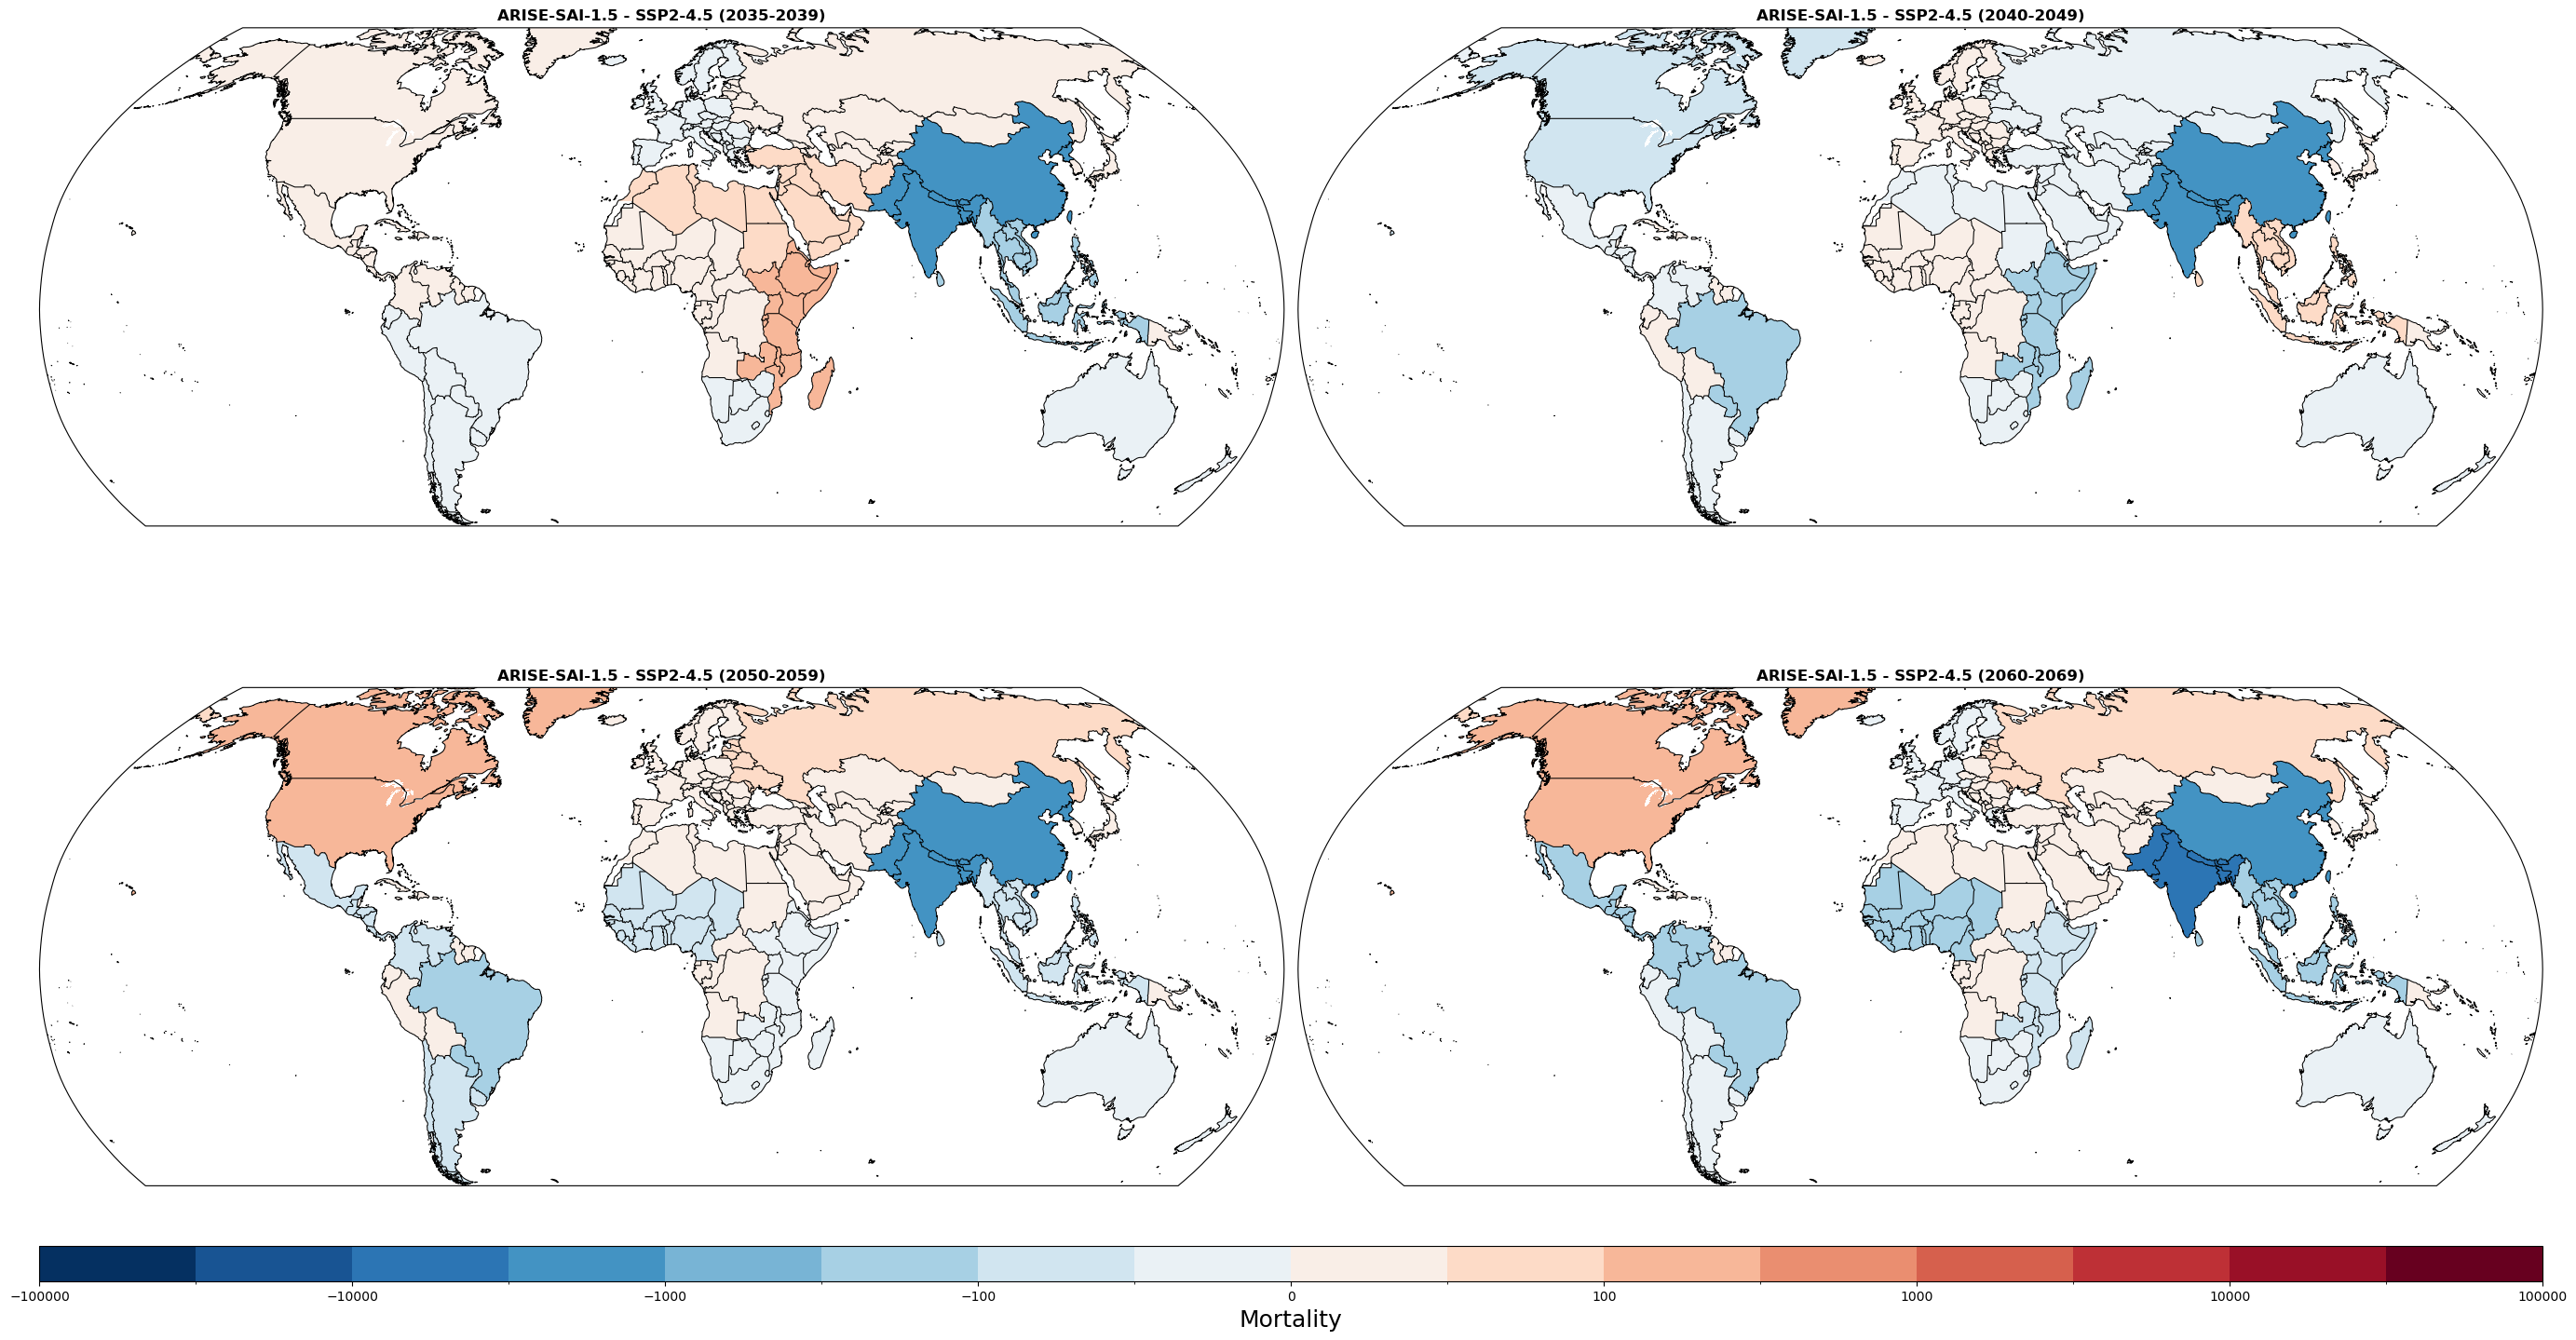

In [8]:
fig = plt.figure(figsize=autosize_figure(2, 2, scale_factor=1.6, xscale_factor=1.3))
gs = GridSpec(3, 2, height_ratios=[20, 20, 1]) # rows, columns

projection = ccrs.Robinson()
crs = ccrs.PlateCarree()

col_map = plt.get_cmap('Reds')

country_borders = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_0_boundary_lines_land',
    scale='50m',
    facecolor='none')

levels=[-100000, -50000, -10000, -5000, -1000, -500, -100, -50, 0, 50, 100, 500, 1000, 5000, 10000, 50000, 100000]

# First panel
ax = fig.add_subplot(gs[0, 0], projection=projection, frameon=True)
cb = land_filter(diff_30s).plot(transform=crs, levels=levels,
                                add_colorbar=False, subplot_kws={'projection': projection})
ax.coastlines(resolution="50m", linewidth=0.75)
ax.add_feature(country_borders, edgecolor='k', linewidth=0.75)
plt.title("ARISE-SAI-1.5 - SSP2-4.5 (2035-2039)", fontweight='bold')

# Second panel
ax = fig.add_subplot(gs[0, 1], projection=projection, frameon=True)
cb = land_filter(diff_40s).plot(transform=crs, levels=levels,
                                add_colorbar=False, subplot_kws={'projection': projection})
ax.coastlines(resolution="50m", linewidth=0.75)
ax.add_feature(country_borders, edgecolor='k', linewidth=0.75)
plt.title("ARISE-SAI-1.5 - SSP2-4.5 (2040-2049)", fontweight='bold')

# Third panel
ax = fig.add_subplot(gs[1, 0], projection=projection, frameon=True)
cb = land_filter(diff_50s).plot(transform=crs, levels=levels,
                                add_colorbar=False, subplot_kws={'projection': projection})
ax.coastlines(resolution="50m", linewidth=0.75)
ax.add_feature(country_borders, edgecolor='k', linewidth=0.75)
plt.title("ARISE-SAI-1.5 - SSP2-4.5 (2050-2059)", fontweight='bold')

# Fourth panel
ax = fig.add_subplot(gs[1, 1], projection=projection, frameon=True)
cb = land_filter(diff_60s).plot(transform=crs, levels=levels,
                                add_colorbar=False, subplot_kws={'projection': projection})
ax.coastlines(resolution="50m", linewidth=0.75)
ax.add_feature(country_borders, edgecolor='k', linewidth=0.75)
plt.title("ARISE-SAI-1.5 - SSP2-4.5 (2060-2069)", fontweight='bold')

# Colorbar
cax = fig.add_subplot(gs[2, :])
col_bar = plt.colorbar(cb, cax=cax, orientation='horizontal')
col_bar.set_label('Mortality', fontsize=18)

plt.tight_layout()